In [3]:
import pandas as pd

data = pd.read_csv("student_dropout_dataset_v3 (1).csv")

data.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [ ]:
## 2.1 Zielvariable

Für dieses Projekt soll vorhergesagt werden, ob ein Student das Studium abbricht oder nicht.  
Dafür wird das Feld **Dropout** verwendet. Dieses Feld enthält die Werte 0 (kein Abbruch) und 1 (Abbruch).

In [4]:
data.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [5]:
data.median(numeric_only=True)

Student_ID                5000.50
Age                         21.00
Family_Income            29740.50
Study_Hours_per_Day          4.00
Attendance_Rate             81.80
Assignment_Delay_Days        2.00
Travel_Time_Minutes         30.20
Stress_Index                 5.50
GPA                          2.35
Semester_GPA                 2.35
CGPA                         2.35
Dropout                      0.00
dtype: float64

In [6]:
data.std(numeric_only=True)

Student_ID                2886.895680
Age                          2.139810
Family_Income            20496.232179
Study_Hours_per_Day          1.295450
Attendance_Rate              8.220930
Assignment_Delay_Days        1.344307
Travel_Time_Minutes         11.918870
Stress_Index                 1.765951
GPA                          1.061717
Semester_GPA                 1.074407
CGPA                         1.072555
Dropout                      0.424270
dtype: float64

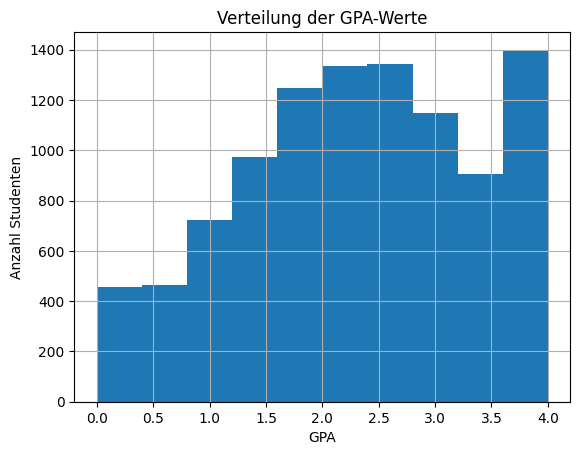

In [8]:
import matplotlib.pyplot as plt

data["GPA"].hist()
plt.title("Verteilung der GPA-Werte")
plt.xlabel("GPA")
plt.ylabel("Anzahl Studenten")
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data["Study_Hours_per_Day_scaled"] = scaler.fit_transform(data[["Study_Hours_per_Day"]])

data[["Study_Hours_per_Day", "Study_Hours_per_Day_scaled"]].head()

,Study_Hours_per_Day,Study_Hours_per_Day_scaled
0,3.36,-0.505327
1,4.30,0.220328
2,4.40,0.297525
3,NaN,NaN
4,4.19,0.135411


In [ ]:
## 2.4 Skalierung der Daten

Das Feld Study_Hours_per_Day wurde skaliert, damit die Werte besser für Machine-Learning-Algorithmen geeignet sind. Bei der Skalierung werden die Daten so transformiert, dass sie eine ähnliche Größenordnung haben. Dadurch wird verhindert, dass Variablen mit großen Zahlen einen stärkeren Einfluss auf das Modell haben als andere Variablen. Für die Skalierung wurde der StandardScaler aus der sklearn-Bibliothek verwendet.